In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import load_data, check_stationarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

global_data = load_data()

C:\Users\Afonso Viveiros\OneDrive\Documentos\TSF-PROJ\utils.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
C:\Users\Afonso Viveiros\OneDrive\Documentos\TSF-PROJ\utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
C:\Users\Afonso Viveiros\OneDrive\Documentos\TSF-PROJ\utils.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [2]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    y_test = np.array(y_test)
    y_pred = np.array(y_pred)

    residuals = y_test - y_pred
    std = np.std(residuals, ddof=1)

    print("Standard Deviation of Residuals:", std)

In [3]:
def recursive_forecast(model, data, n_steps=12, n_lags=12):
    """
    Generate recursive multi-step forecasts for monthly data using a trained model.
    
    Parameters:
    - model: trained ML model (e.g., XGBoost)
    - data: pd.DataFrame with a 'y' column and datetime index
    - n_steps: number of months to forecast
    - n_lags: number of lag features to use
    
    Returns:
    - forecast: pd.Series of predicted values with datetime index
    """
    last_data = data.copy()
    forecast = []
    
    for i in range(n_steps):
        # Compute lag features
        lags = [last_data['y'].iloc[-lag] for lag in range(1, n_lags + 1)]
        
        # Rolling statistics
        rolling_3 = np.mean([last_data['y'].iloc[-j] for j in range(1, min(4, len(last_data)+1))])
        rolling_6 = np.mean([last_data['y'].iloc[-j] for j in range(1, min(7, len(last_data)+1))])
        
        # Month features
        next_month = last_data.index[-1] + pd.DateOffset(months=1)
        month_sin = np.sin(2 * np.pi * next_month.month / 12)
        month_cos = np.cos(2 * np.pi * next_month.month / 12)
        
        # Combine features
        X_next = np.array(lags + [rolling_3, rolling_6, next_month.month, month_sin, month_cos]).reshape(1, -1)
        
        # Predict next value
        y_next = model.predict(X_next)[0]
        forecast.append(y_next)
        
        # Append prediction for next iteration
        last_data = pd.concat([last_data, pd.DataFrame({'y': [y_next]}, index=[next_month])])
    
    forecast_index = pd.date_range(start=last_data.index[-n_steps], periods=n_steps, freq='MS')
    return pd.Series(forecast, index=forecast_index)

    

In [4]:
def get_data(target):
    loaded_data = global_data
    data = pd.DataFrame({
        'date': loaded_data['date'],
        'y': loaded_data[target]
    })
    
    data.set_index('date', inplace=True)
    
    # Add lag features (1 to 12 months)
    for lag in range(1, 13):
        data[f'lag_{lag}'] = data['y'].shift(lag)
    
    # Add rolling mean features
    data['rolling_3'] = data['y'].shift(1).rolling(3).mean()
    data['rolling_6'] = data['y'].shift(1).rolling(6).mean()
    
    # Add cyclical month features
    data['month'] = data.index.month
    data['month_sin'] = np.sin(2 * np.pi * data['month']/12)
    data['month_cos'] = np.cos(2 * np.pi * data['month']/12)
    
    # Drop rows with NaN from lag/rolling features
    data.dropna(inplace=True)

    return data

In [5]:
def get_model_prediction(model, train, steps):
    X_train = train.drop(columns=['y'])
    y_train = train['y']

    model.fit(X_train, y_train)
    return recursive_forecast(model, train, n_steps=steps)

In [6]:
split_idx = int(len(global_data)*0.8)
max_data = get_data('tmax')
min_data = get_data('tmin')
test_diff = max_data.iloc[split_idx:]['y'] - min_data.iloc[split_idx:]['y']

In [7]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

window_size = 96  # 8 years
forecast_horizon = 24  # 2-year ahead

preds = []
actuals = []
dates = []
lb_results = []

max_data = get_data('tmax')
min_data = get_data('tmin')
diff_data = get_data('tdiff')

for start in range(0, len(diff_data) - window_size - forecast_horizon + 1, forecast_horizon):
    # Training and test windows
    max_train_window = max_data.iloc[start:start + window_size]
    min_train_window = min_data.iloc[start:start + window_size]
    diff_test_window = diff_data.iloc[start + window_size:start + window_size + forecast_horizon]

    rf_max = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        random_state=42
    )
    
    rf_min = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        random_state=42
    )
    

    max_pred_rf = get_model_prediction(rf_max, max_train_window, forecast_horizon)
    min_pred_rf = get_model_prediction(rf_min, min_train_window, forecast_horizon)
    diff_pred_rf = max_pred_rf - min_pred_rf

    preds.extend(diff_pred_rf.values)
    actuals.extend(diff_test_window['y'].values)
    dates.extend(diff_test_window.index)

    residuals = diff_test_window['y'].values - diff_pred_rf.values

    # Ljung–Box at seasonal lag
    lb = acorr_ljungbox(
        residuals,
        lags=[12],
        return_df=True
    )

    lb_results.append({
        'ds': diff_test_window.index[-1],   # end of forecast window
        'lb_stat': lb['lb_stat'].iloc[0],
        'p_value': lb['lb_pvalue'].iloc[0]
    })

evaluate(actuals, preds)
#DataFrame for plotting
results_df = pd.DataFrame({
    'ds': dates,
    'actual': actuals,
    'predicted': preds
})


MAE: 1.3481082521434458
RMSE: 1.7184014309427438
Standard Deviation of Residuals: 1.6987093687482444


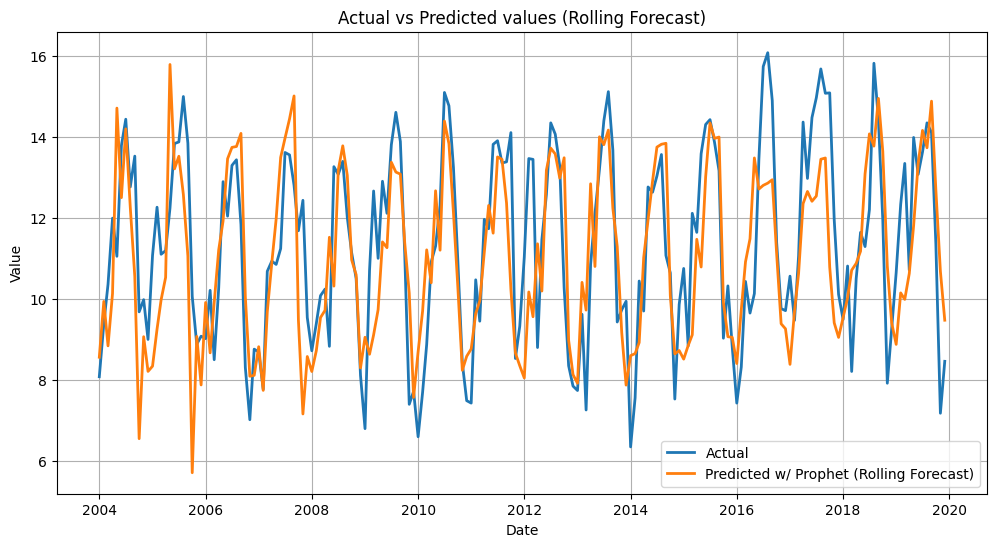

In [8]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(results_df["ds"], results_df["actual"], label="Actual", linewidth=2)
plt.plot(results_df["ds"], results_df["predicted"], label="Predicted w/ Prophet (Rolling Forecast)", linewidth=2)
plt.title("Actual vs Predicted values (Rolling Forecast)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

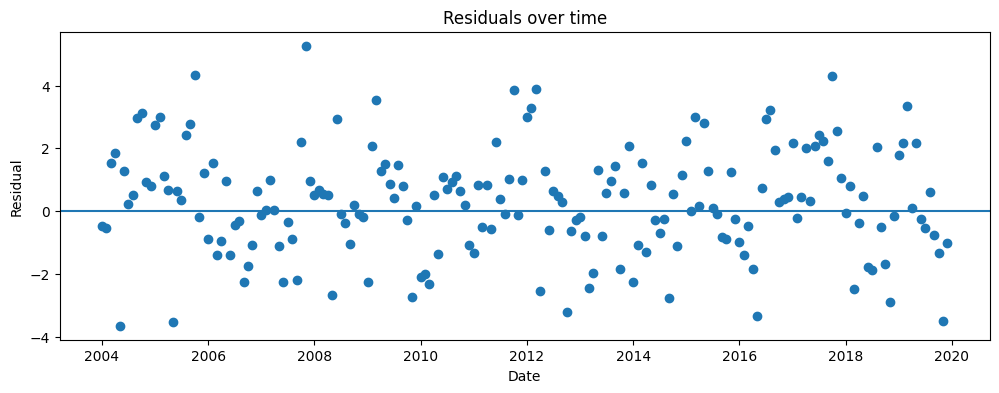

In [9]:
residuals = np.array(actuals) - np.array(preds)

plt.figure(figsize=(12, 4))
plt.scatter(results_df["ds"], residuals)
plt.axhline(0)
plt.title("Residuals over time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

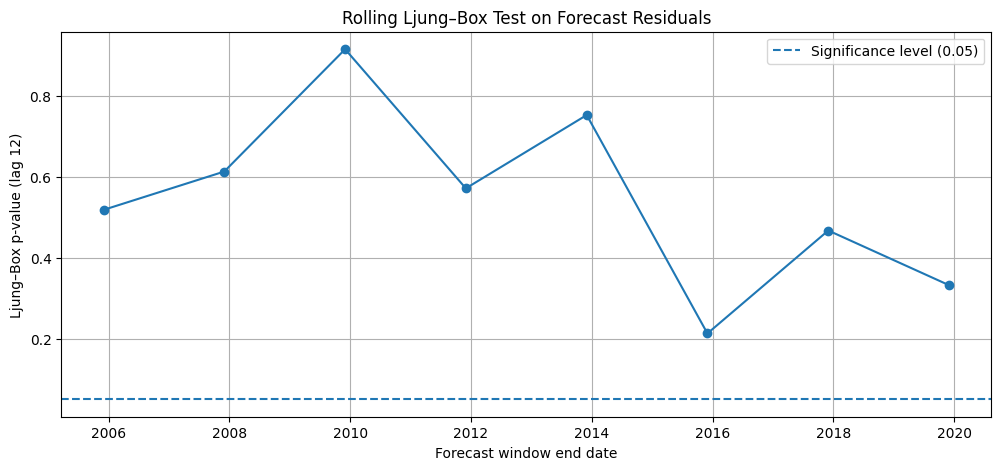

In [10]:
from plots import plot_lb_test

lb_df = pd.DataFrame(lb_results)

plot_lb_test(lb_df)

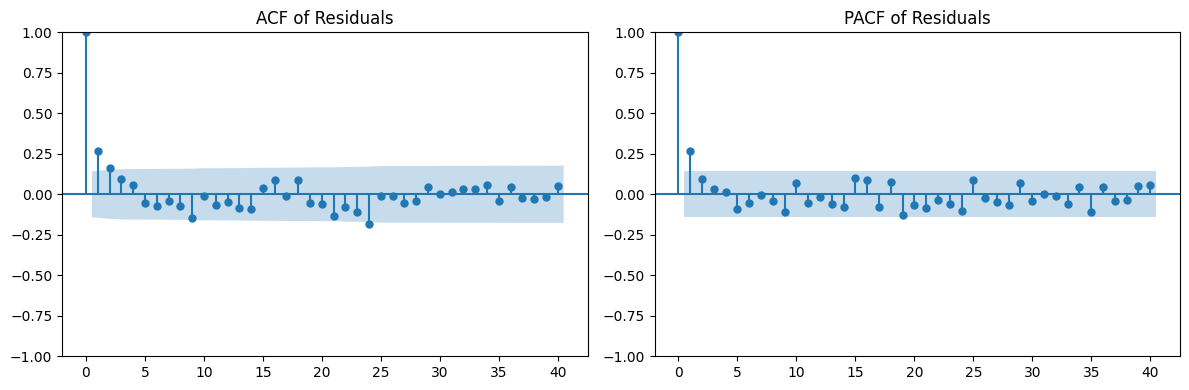

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

In [ ]:
"""daqui praticamente nada interessa """
from xgboost import XGBRegressor

xgb_max = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_min = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

max_pred_xgb = get_model_prediction(xgb_max, max_data, split_idx)
min_pred_xgb = get_model_prediction(xgb_min, min_data, split_idx)
pred_diff_xgb = max_pred_xgb - min_pred_xgb
evaluate(test_diff, pred_diff_xgb)

ValueError: Found input variables with inconsistent numbers of samples: [49, 240]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(pred_diff_rf.index, test_diff, label="Actual", linewidth=2)
plt.plot(pred_diff_rf.index, pred_diff_rf, label="Predicted w/ Random Forest", linewidth=2)
plt.plot(pred_diff_rf.index, pred_diff_xgb, label="Predicted w/ XGBoost", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()